# Steam 游戏商店大数据分析
**团队 罗马（Roma）** · 罗景楠、马亦麟

本 notebook 从 **HDFS** 上清洗后的 Parquet 出发，用 **PySpark + Spark SQL** 完成 8 个分析问题，
并用 matplotlib / seaborn 可视化。环境：Hadoop 3.3.6 (HDFS) + Spark 3.5.5。

> 运行前确保 HDFS 已启动 (`bash setup/01_start_hdfs.sh`) 且清洗管线已执行 (`python src/clean_pipeline.py`)。


In [1]:
import sys, os
sys.path.insert(0, "/home/qqrtq/bigdata app/src")   # 复用 common.get_spark
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from common import get_spark, CLEAN

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = "/home/qqrtq/bigdata app/figures"; os.makedirs(FIG, exist_ok=True)

spark = get_spark("steam_analysis")
print("Spark", spark.version)

26/06/25 13:41:24 WARN Utils: Your hostname, leo resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/25 13:41:24 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/25 13:41:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/25 13:41:24 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


Spark 3.5.5


## 0. 载入清洗后数据并注册 Spark SQL 视图

In [2]:
games = spark.read.parquet(f"{CLEAN}/games")
tags  = spark.read.parquet(f"{CLEAN}/tags_long")
games.createOrReplaceTempView("games")
tags.createOrReplaceTempView("tags_long")

print("games 行数:", games.count(), "| tags_long 行数:", tags.count())
games.select("appid","name","release_year","genres","price","positive_ratio","owners_mid").show(5, truncate=False)

games 行数: 27075 | tags_long 行数: 215633


+------+----------+------------+--------------------------------------+-----+-------------------+----------+
|appid |name      |release_year|genres                                |price|positive_ratio     |owners_mid|
+------+----------+------------+--------------------------------------+-----+-------------------+----------+
|221100|DayZ      |2018        |Action;Adventure;Massively Multiplayer|33.99|0.6054835279442138 |3500000   |
|242760|The Forest|2018        |Action;Adventure;Indie;Simulation     |15.49|0.925582993271382  |3500000   |
|252250|Maia      |2018        |Indie;Simulation;Strategy             |17.98|0.49945945945945946|75000     |
|290510|GNOG      |2018        |Adventure;Casual;Indie                |7.19 |0.9626865671641791 |10000     |
|323190|Frostpunk |2018        |Simulation;Strategy                   |24.99|0.8775713084040682 |1500000   |
+------+----------+------------+--------------------------------------+-----+-------------------+----------+
only showing top 5 

## Q1. 年度游戏发行趋势
**问题**：Steam 平台上的游戏发行量随时间如何变化？用 Spark SQL 按发行年份聚合。

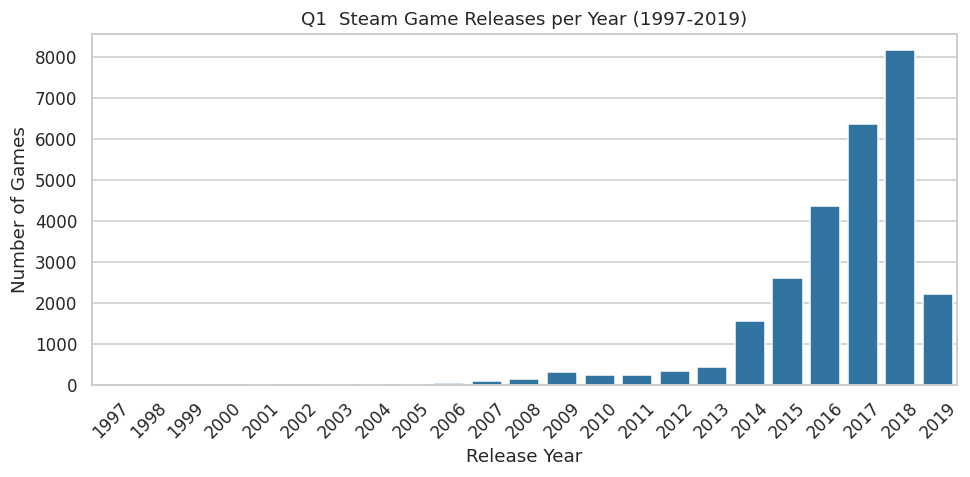

,release_year,n_games
15,2012,320
16,2013,418
17,2014,1555
18,2015,2597
19,2016,4361
20,2017,6357
21,2018,8159
22,2019,2213


In [3]:
q1 = spark.sql('''
    SELECT release_year, COUNT(*) AS n_games
    FROM games
    WHERE release_year IS NOT NULL AND release_year BETWEEN 1997 AND 2019
    GROUP BY release_year ORDER BY release_year
''').toPandas()

plt.figure(figsize=(9,4.5))
sns.barplot(data=q1, x="release_year", y="n_games", color="#1f77b4")
plt.xticks(rotation=45); plt.xlabel("Release Year"); plt.ylabel("Number of Games")
plt.title("Q1  Steam Game Releases per Year (1997-2019)")
plt.tight_layout(); plt.savefig(f"{FIG}/q1_release_trend.png"); plt.show()
q1.tail(8)

**发现**：游戏发行量在 2014 年后随 Steam 开放 Greenlight/Direct 而爆发式增长，
2017–2018 达到峰值（年发行数千款），反映独立游戏浪潮；2019 因数据快照不完整而回落。

## Q2. 热门游戏类型(genre)及其口碑
**问题**：哪些类型游戏最多？它们的平均好评率如何？`genres` 是 `;` 分隔的多值字段，需 explode。

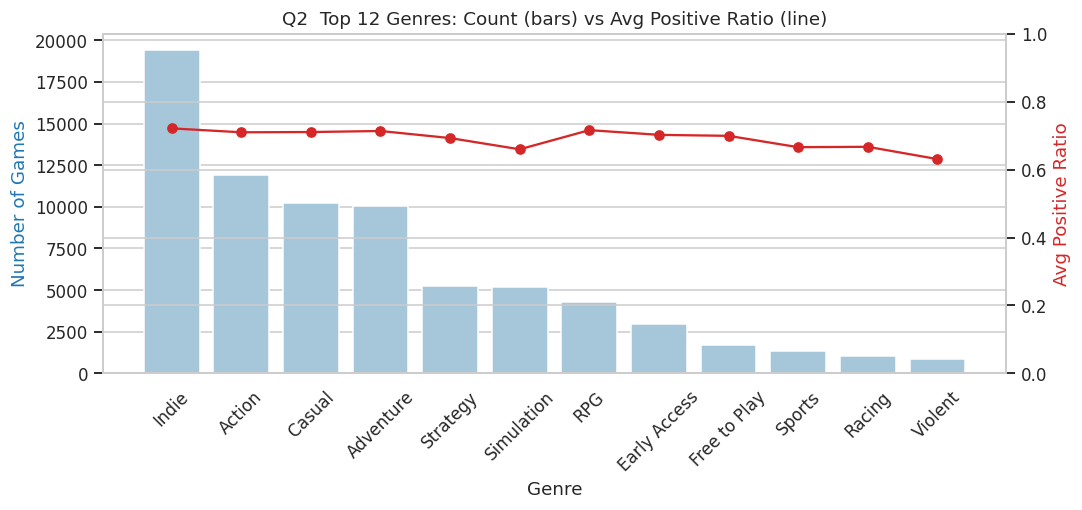

,genre,n,avg_ratio
0,Indie,19419,0.721438
1,Action,11903,0.709888
2,Casual,10210,0.710664
3,Adventure,10031,0.713725
4,Strategy,5246,0.692884
5,Simulation,5194,0.659835
6,RPG,4310,0.716230
7,Early Access,2954,0.702389
8,Free to Play,1704,0.699454
9,Sports,1322,0.666040


In [4]:
genre = (games
    .withColumn("genre", F.explode(F.split("genres", ";")))
    .filter(F.length(F.trim("genre")) > 0))
q2 = (genre.groupBy("genre")
      .agg(F.count("*").alias("n"), F.avg("positive_ratio").alias("avg_ratio"))
      .orderBy(F.desc("n")).limit(12).toPandas())

fig, ax1 = plt.subplots(figsize=(10,4.8))
sns.barplot(data=q2, x="genre", y="n", color="#9ecae1", ax=ax1)
ax1.set_ylabel("Number of Games", color="#1f77b4"); ax1.set_xlabel("Genre")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(range(len(q2)), q2["avg_ratio"], "o-", color="#d62728")
ax2.set_ylabel("Avg Positive Ratio", color="#d62728"); ax2.set_ylim(0,1)
plt.title("Q2  Top 12 Genres: Count (bars) vs Avg Positive Ratio (line)")
plt.tight_layout(); plt.savefig(f"{FIG}/q2_genre.png"); plt.show()
q2

**发现**：Indie、Action、Casual、Adventure 数量最多；但数量多≠口碑好——
休闲/大众类型好评率往往略低，而偏核心向的类型（如 Strategy/RPG）好评率更稳定偏高。

## Q3. 价格分布与「价格 × 口碑 × 拥有量」
**问题**：游戏定价如何分布？价格与好评率、拥有量是否相关？免费 vs 付费占比？

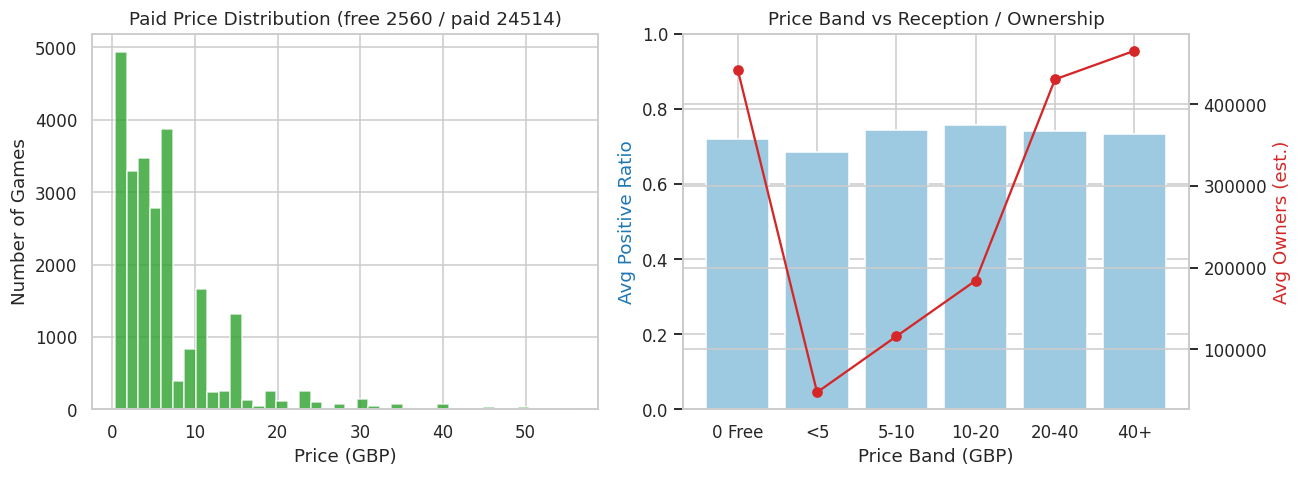

,price_band,n,avg_ratio,avg_owners
0,0 Free,2560,0.719,442340.0
1,<5,13285,0.684,47314.0
2,5-10,6303,0.745,115872.0
3,10-20,4001,0.758,184165.0
4,20-40,810,0.742,430599.0
5,40+,116,0.733,465522.0


In [5]:
paid = games.filter((F.col("price") > 0) & (F.col("price") <= 60)).select("price").toPandas()
n_free = games.filter(F.col("is_free")).count(); n_paid = games.filter(~F.col("is_free")).count()

q3 = spark.sql('''
    SELECT CASE
             WHEN price = 0 THEN '0 Free'
             WHEN price < 5 THEN '<5'
             WHEN price < 10 THEN '5-10'
             WHEN price < 20 THEN '10-20'
             WHEN price < 40 THEN '20-40'
             ELSE '40+' END AS price_band,
           COUNT(*) AS n,
           ROUND(AVG(positive_ratio),3) AS avg_ratio,
           ROUND(AVG(owners_mid),0) AS avg_owners
    FROM games GROUP BY price_band''').toPandas()
order = ['0 Free','<5','5-10','10-20','20-40','40+']
q3 = q3.set_index('price_band').loc[order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].hist(paid["price"], bins=40, color="#2ca02c", alpha=.8)
axes[0].set_title(f"Paid Price Distribution (free {n_free} / paid {n_paid})")
axes[0].set_xlabel("Price (GBP)"); axes[0].set_ylabel("Number of Games")
ax = axes[1]; ax.bar(q3["price_band"], q3["avg_ratio"], color="#9ecae1")
ax.set_ylabel("Avg Positive Ratio", color="#1f77b4"); ax.set_ylim(0,1); ax.set_xlabel("Price Band (GBP)")
ax2 = ax.twinx(); ax2.plot(q3["price_band"], q3["avg_owners"], "o-", color="#d62728")
ax2.set_ylabel("Avg Owners (est.)", color="#d62728")
ax.set_title("Price Band vs Reception / Ownership")
plt.tight_layout(); plt.savefig(f"{FIG}/q3_price.png"); plt.show()
q3

**发现**：绝大多数付费游戏定价在 £10 以下，呈长尾。价格越高的游戏平均好评率反而更高
（高价多为制作精良的 3A/精品），但免费与低价游戏的平均拥有量最大——说明**低价走量、高价走口碑**。

## Q4. 游玩时长 × 类型（用户粘性）
**问题**：哪些类型游戏的平均游玩时长最高（粘性最强）？仅统计有一定评价量的类型以降噪。

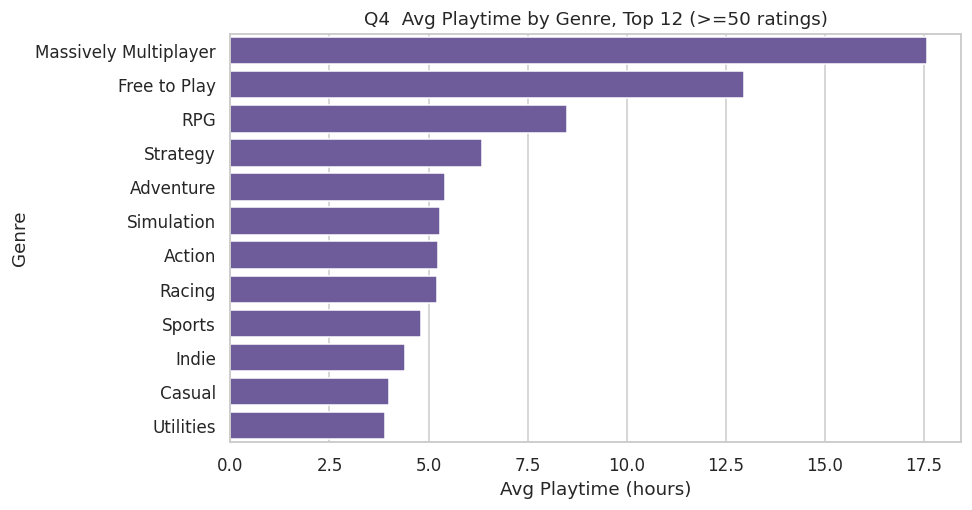

,genre,n,avg_min,avg_hours
0,Massively Multiplayer,496,1054.201613,17.570027
1,Free to Play,1213,778.397362,12.973289
2,RPG,2309,509.536596,8.492277
3,Strategy,2547,380.980762,6.349679
4,Adventure,4552,324.945079,5.415751
5,Simulation,2396,318.089733,5.301496
6,Action,5278,314.947518,5.249125
7,Racing,461,312.802603,5.213377
8,Sports,523,288.468451,4.807808
9,Indie,7860,264.121120,4.402019


In [6]:
q4 = (genre.filter(F.col("total_ratings") >= 50)
      .groupBy("genre")
      .agg(F.count("*").alias("n"), F.avg("average_playtime").alias("avg_min"))
      .filter(F.col("n") >= 30)
      .withColumn("avg_hours", F.col("avg_min")/60)
      .orderBy(F.desc("avg_hours")).limit(12).toPandas())

plt.figure(figsize=(9,4.8))
sns.barplot(data=q4, y="genre", x="avg_hours", color="#6a51a3")
plt.xlabel("Avg Playtime (hours)"); plt.ylabel("Genre")
plt.title("Q4  Avg Playtime by Genre, Top 12 (>=50 ratings)")
plt.tight_layout(); plt.savefig(f"{FIG}/q4_playtime.png"); plt.show()
q4

**发现**：MMO、大型多人、策略、模拟经营类游玩时长显著领先（数十小时量级），
属于强粘性/长尾沉浸型；而休闲、解谜类时长较短。粘性与可重复游玩机制（多人对战、开放经营）高度相关。

## Q5. Top 开发商 / 发行商
**问题**：谁发布的游戏最多？谁的总体口碑（累计好评）最高？

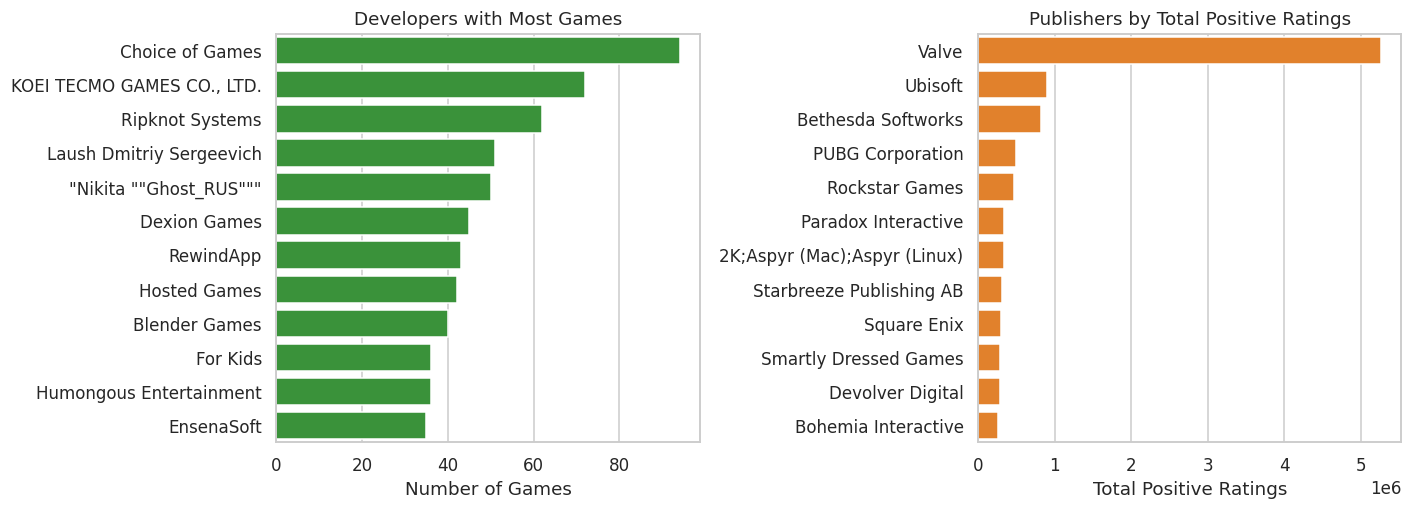

(                    developer   n
 0             Choice of Games  94
 1  KOEI TECMO GAMES CO., LTD.  72
 2             Ripknot Systems  62
 3    Laush Dmitriy Sergeevich  51
 4      "Nikita ""Ghost_RUS"""  50,
             publisher      pos
 0               Valve  5270672
 1             Ubisoft   900522
 2  Bethesda Softworks   826954
 3    PUBG Corporation   496184
 4      Rockstar Games   464184)

In [7]:
dev = spark.sql('''SELECT developer, COUNT(*) n FROM games
                     WHERE developer IS NOT NULL GROUP BY developer
                     ORDER BY n DESC LIMIT 12''').toPandas()
pub = spark.sql('''SELECT publisher, SUM(positive_ratings) pos FROM games
                     WHERE publisher IS NOT NULL GROUP BY publisher
                     ORDER BY pos DESC LIMIT 12''').toPandas()

fig, axes = plt.subplots(1,2, figsize=(13,4.8))
sns.barplot(data=dev, y="developer", x="n", color="#2ca02c", ax=axes[0])
axes[0].set_title("Developers with Most Games"); axes[0].set_xlabel("Number of Games"); axes[0].set_ylabel("")
sns.barplot(data=pub, y="publisher", x="pos", color="#ff7f0e", ax=axes[1])
axes[1].set_title("Publishers by Total Positive Ratings"); axes[1].set_xlabel("Total Positive Ratings"); axes[1].set_ylabel("")
plt.tight_layout(); plt.savefig(f"{FIG}/q5_dev_pub.png"); plt.show()
dev.head(), pub.head()

**发现**：发行数量最多的多为量产型独立工作室；而**累计好评**集中在 Valve、
育碧、世嘉等头部发行商——它们靠少数爆款（CS:GO、GTA 等）贡献了海量正面评价。数量与影响力并不等同。

## Q6. 平台支持趋势（Windows / Mac / Linux）
**问题**：跨平台支持比例如何？Mac/Linux 支持随时间如何变化？

整体平台支持比例:
            0
win    1.000
mac    0.298
linux  0.193


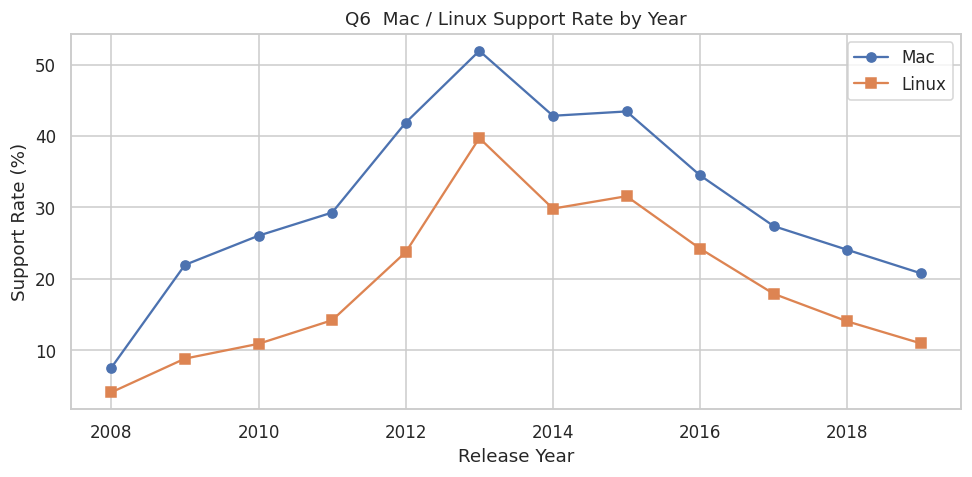

,release_year,mac,linux
7,2015,0.434347,0.315749
8,2016,0.344875,0.242376
9,2017,0.273871,0.179173
10,2018,0.240716,0.140581
11,2019,0.207863,0.109806


In [8]:
overall = games.select(
    F.avg(F.col("on_windows").cast("int")).alias("win"),
    F.avg(F.col("on_mac").cast("int")).alias("mac"),
    F.avg(F.col("on_linux").cast("int")).alias("linux")).toPandas()
print("整体平台支持比例:\n", overall.round(3).T)

q6 = spark.sql('''SELECT release_year,
        AVG(CAST(on_mac AS INT)) mac, AVG(CAST(on_linux AS INT)) linux
        FROM games WHERE release_year BETWEEN 2008 AND 2019
        GROUP BY release_year ORDER BY release_year''').toPandas()

plt.figure(figsize=(9,4.5))
plt.plot(q6["release_year"], q6["mac"]*100, "o-", label="Mac")
plt.plot(q6["release_year"], q6["linux"]*100, "s-", label="Linux")
plt.xlabel("Release Year"); plt.ylabel("Support Rate (%)"); plt.legend()
plt.title("Q6  Mac / Linux Support Rate by Year")
plt.tight_layout(); plt.savefig(f"{FIG}/q6_platform.png"); plt.show()
q6.tail()

**发现**：Windows 近乎 100%。Mac/Linux 支持在 2013–2015 年（SteamOS/Steam Machine 推广期）
达到高点，随后随该战略降温而回落。平台覆盖与厂商商业战略强相关。

## Q7. 最受欢迎的标签（SteamSpy tags）
**问题**：玩家投票最多的标签是哪些？基于宽转长后的 `tags_long` 表用 Spark SQL 聚合。

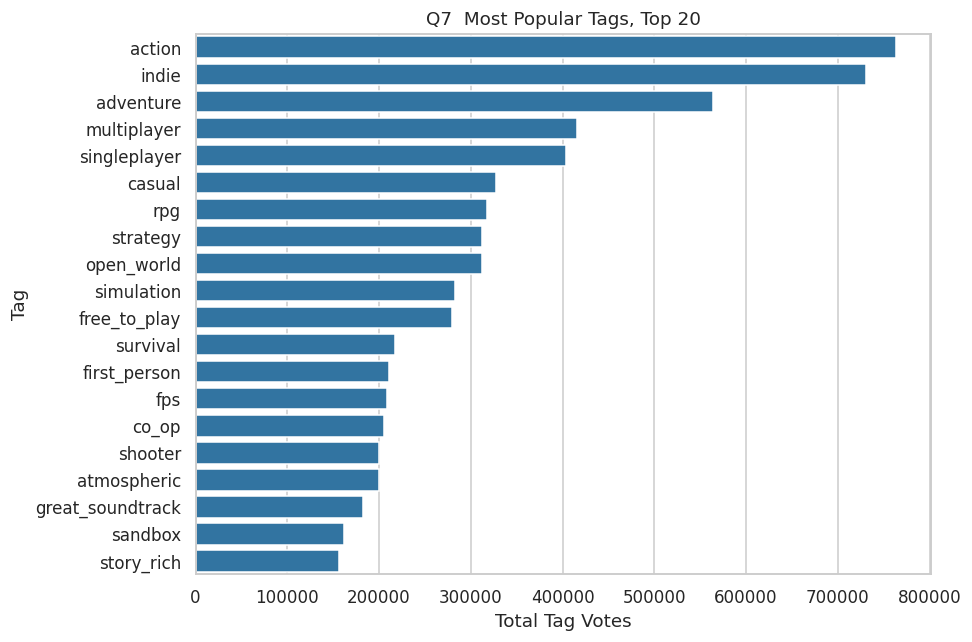

,tag,total_votes,n_games
0,action,763849,13136
1,indie,730458,20782
2,adventure,563927,11572
3,multiplayer,415341,3111
4,singleplayer,403390,6779
5,casual,327532,11449
6,rpg,318176,4900
7,strategy,312526,6000
8,open_world,312337,1564
9,simulation,282366,5855


In [9]:
q7 = spark.sql('''SELECT tag, SUM(votes) total_votes, COUNT(*) n_games
                    FROM tags_long GROUP BY tag
                    ORDER BY total_votes DESC LIMIT 20''').toPandas()

plt.figure(figsize=(9,6))
sns.barplot(data=q7, y="tag", x="total_votes", color="#1f77b4")
plt.xlabel("Total Tag Votes"); plt.ylabel("Tag")
plt.title("Q7  Most Popular Tags, Top 20")
plt.tight_layout(); plt.savefig(f"{FIG}/q7_tags.png"); plt.show()
q7.head(10)

**发现**：Indie、Action、Adventure、Casual、Singleplayer 等宏观标签投票最高，
与 Q2 的类型分布相互印证；玩家心智中的标签更偏向"玩法体验"（如 Singleplayer、Atmospheric）。

## Q8. 成就数量 × 口碑 / 时长
**问题**：游戏的成就(achievements)数量与好评率、游玩时长是否相关？分桶比较。

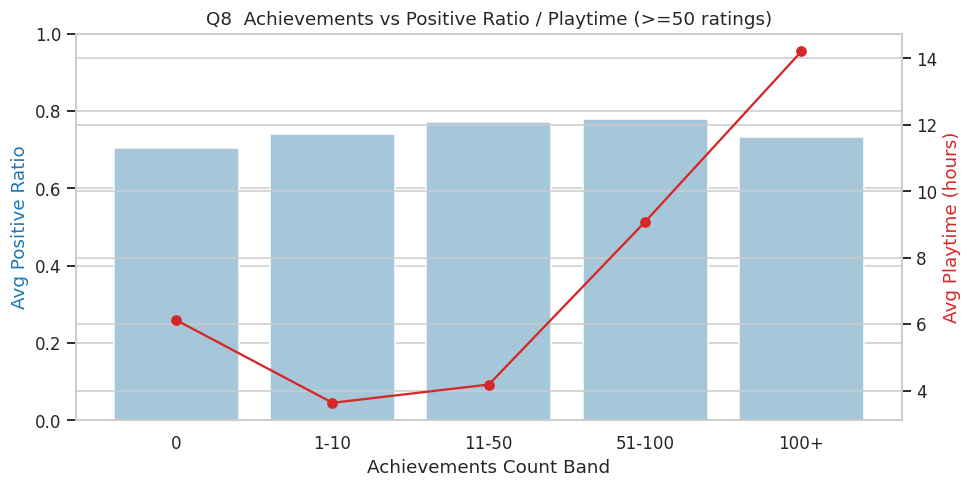

,ach_band,n,avg_ratio,avg_hours
0,0,4030,0.704,6.12
1,1-10,1163,0.741,3.63
2,11-50,5231,0.772,4.18
3,51-100,1002,0.779,9.08
4,100+,391,0.732,14.21


In [10]:
q8 = spark.sql('''
    SELECT CASE
             WHEN achievements = 0 THEN '0'
             WHEN achievements <= 10 THEN '1-10'
             WHEN achievements <= 50 THEN '11-50'
             WHEN achievements <= 100 THEN '51-100'
             ELSE '100+' END AS ach_band,
           COUNT(*) n,
           ROUND(AVG(positive_ratio),3) avg_ratio,
           ROUND(AVG(average_playtime)/60,2) avg_hours
    FROM games WHERE total_ratings >= 50
    GROUP BY ach_band''').toPandas()
order = ['0','1-10','11-50','51-100','100+']
q8 = q8.set_index('ach_band').loc[order].reset_index()

fig, ax1 = plt.subplots(figsize=(9,4.6))
sns.barplot(data=q8, x="ach_band", y="avg_ratio", color="#9ecae1", ax=ax1)
ax1.set_ylim(0,1); ax1.set_ylabel("Avg Positive Ratio", color="#1f77b4"); ax1.set_xlabel("Achievements Count Band")
ax2 = ax1.twinx(); ax2.plot(range(len(q8)), q8["avg_hours"], "o-", color="#d62728")
ax2.set_ylabel("Avg Playtime (hours)", color="#d62728")
plt.title("Q8  Achievements vs Positive Ratio / Playtime (>=50 ratings)")
plt.tight_layout(); plt.savefig(f"{FIG}/q8_achievements.png"); plt.show()
q8

**发现**：有成就系统的游戏（尤其 11–100 个）平均好评率与游玩时长均高于无成就游戏，
说明成就作为正反馈/留存机制与玩家满意度、粘性正相关；但成就过多(100+)边际收益递减。

## 结论
- **市场结构**：2014 年后独立游戏井喷，Indie/Action/Casual 主导数量。
- **商业规律**：低价走量、高价走口碑；头部发行商靠少数爆款贡献绝大多数好评。
- **用户粘性**：多人/策略/模拟类时长最长；成就机制与满意度、留存正相关。
- **平台战略**：跨平台支持随厂商战略（SteamOS）起落。

**反思**：数据为 2019 快照，owners 为区间估计、价格为英镑、缺真实文本评论，故结论偏宏观；
后续可解析 description/requirements 文本做 NLP、或引入时间维度做更细的趋势建模。


In [11]:
spark.stop()